# 서울시 119 구급 공공 API 수집 (v3)

**목적** : 자치구별 월간 이송 건수 예측 모델용 학습 데이터 + 실시간 응급실 병상(참고용) 수집

| 구분 | 출처 | 저장 파일 |
|---|---|---|
| 월별 출동·이송 | 소방청 구급통계 API | `ml_data/ambulance_monthly.csv` |
| 실시간 응급실 병상 | 국립중앙의료원 API + 안전데이터(DSSP-IF-00242, 강북·마포 일반 병상 참고) | `outputs/realtime_er_beds.csv` |
| 자치구별 병상수(참고용) | 안전데이터(DSSP-IF-00606) | `ml_data/gu_beds_yearly.csv` |

## 0. 환경 설정

In [1]:
import os
import time
import warnings
import requests
import urllib3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from bs4 import BeautifulSoup
from dotenv import load_dotenv
from IPython.display import display

warnings.filterwarnings("ignore")
urllib3.disable_warnings()          # 안전데이터포털 verify=False 경고 숨김

load_dotenv(override=True)
KEY = os.getenv("DATA_GO_KR_KEY")           # 공공데이터포털
KEY_00242 = os.getenv("SAFETY_KEY_00242")   # 안전데이터 실시간 병상
KEY_00606 = os.getenv("SAFETY_KEY_00606")   # 안전데이터 병상수

# 경로 (팀원 환경에 맞게 BASE_DIR만 수정)
BASE_DIR = "C:/ai/source/09_Project/cheolhyeon_jo"
SRC_DIR = f"{BASE_DIR}/data"
OUT_DIR = f"{BASE_DIR}/outputs"
ML_DIR = f"{BASE_DIR}/ml_data"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(ML_DIR, exist_ok=True)

CACHE_PATH = f"{OUT_DIR}/ambulance_monthly_cache.csv"   # 이어받기용
NODATA_PATH = f"{OUT_DIR}/ambulance_nodata.csv"         # '데이터 없음' 확정 목록
MODEL_PATH = f"{ML_DIR}/ambulance_monthly.csv"
BEDS_PATH = f"{OUT_DIR}/realtime_er_beds.csv"
BEDS_YEARLY_PATH = f"{ML_DIR}/gu_beds_yearly.csv"
SAFETY_CSV = f"{SRC_DIR}/국립중앙의료원_의료기관_실시간_병상정보.csv"

START_YM, END_YM = "201701", "202512"   # 학습 데이터 기간
WAIT = 1.0                              # 요청 간격(초)
STALE_HOURS = 24                        # 이보다 오래된 병상 정보는 '정보 없음'
SUPPLEMENT_GU = ["강북구", "마포구"]     # 안전데이터로 보완할 자치구

GU_CODE = {
    "11110": "종로구", "11140": "중구", "11170": "용산구", "11200": "성동구", "11215": "광진구",
    "11230": "동대문구", "11260": "중랑구", "11290": "성북구", "11305": "강북구", "11320": "도봉구",
    "11350": "노원구", "11380": "은평구", "11410": "서대문구", "11440": "마포구", "11470": "양천구",
    "11500": "강서구", "11530": "구로구", "11545": "금천구", "11560": "영등포구", "11590": "동작구",
    "11620": "관악구", "11650": "서초구", "11680": "강남구", "11710": "송파구", "11740": "강동구",
}
GU_LIST = sorted(GU_CODE.values())

# 소방서 개서 이력 : 신설 자치구 -> (관할을 넘겨준 자치구, 개서 월)
SPLIT_HISTORY = {"성동구": ("광진구", "2017-07-01"), "금천구": ("구로구", "2022-01-01")}



def set_korean_font():
    candidates = [
        "C:/Windows/Fonts/malgun.ttf",                            # Windows
        "/System/Library/Fonts/Supplemental/AppleGothic.ttf",     # macOS
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",        # Linux
    ]
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            name = fm.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = name
            return name
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
        if name in installed:
            plt.rcParams["font.family"] = name
            return name
    return None


sns.set_style("dark")       # 스타일을 먼저 설정해야 폰트가 덮어써지지 않음
set_korean_font()
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 5)

### 0-1. 공통 요청 함수

**작동 원리**
- 실패 시 대기 시간 2배씩 증가 재시도 (2초 → 4초 → 8초)
- 사용자 정의 예외 `QuotaError` : 일일 호출 한도 소진 시 전체 중단
- XML 본문 속 오류 코드 확인 (HTTP 200이어도 오류 가능)
- `BeautifulSoup(..., "xml")` 로 `item` 태그 → 딕셔너리 리스트

In [2]:
class QuotaError(Exception):
    pass


def get(url, params, verify=True, retries=3):
    status = None
    for i in range(retries):
        try:
            res = requests.get(url, params=params, timeout=30, verify=verify)
            if res.status_code == 200:
                return res
            status = res.status_code
        except requests.RequestException:
            pass
        time.sleep(2 ** (i + 1))
    if status == 429:
        raise QuotaError("일일 호출 한도 소진")
    raise RuntimeError(f"요청 실패 (상태 코드 {status})")


def parse_xml(text):
    """XML 응답 -> (행 리스트, 전체 건수)"""
    soup = BeautifulSoup(text, "xml")
    for code_tag, msg_tag in [("returnReasonCode", "returnAuthMsg"), ("resultCode", "resultMsg")]:
        code, msg = soup.find(code_tag), soup.find(msg_tag)
        if code and code.text != "00":
            msg = msg.text if msg else ""
            if code.text == "22" or "LIMITED" in msg:
                raise QuotaError(msg)
            raise RuntimeError(f"API 오류 {code.text}: {msg}")
    rows = [{c.name: c.text for c in item.find_all(recursive=False)} for item in soup.find_all("item")]
    total = soup.find("totalCount")
    return rows, int(total.text) if total else 0


def fetch_safety(api_id, key, num_rows=1000):
    """안전데이터포털 JSON API 전체 페이지 수집"""
    frames, page = [], 1
    while True:
        params = {"serviceKey": key, "returnType": "json", "pageNo": page, "numOfRows": num_rows}
        data = get(f"https://www.safetydata.go.kr/V2/api/{api_id}", params, verify=False).json()
        header = data.get("header", {})
        code = str(header.get("resultCode", "00"))
        if code == "22":
            raise QuotaError(header.get("resultMsg"))
        if code.strip("0"):
            raise RuntimeError(f"{api_id} 오류 {code}: {header.get('resultMsg')}")

        body = data.get("body") or []
        if isinstance(body, dict):      # 1건이면 딕셔너리로 옴
            body = [body]
        if not body:
            break
        frames.append(pd.DataFrame(body))
        if page * num_rows >= int(data.get("totalCount", 0)):
            break
        page += 1
        time.sleep(WAIT)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

---
## 1. 소방청 구급통계 → 예측 모델용 월별 데이터

### 1-1. 소방서 → 자치구 매핑 + 조회 함수

**작동 원리**
- 정규표현식 `str.extract` 로 관할구역에서 `○○구` 추출
- 소방서별 최빈값(`mode`) 자치구 선택
- 소방서·접수년월 단위 조회, totalCount 기준 페이지 반복

In [3]:
station_df = pd.read_csv(f"{SRC_DIR}/서울소방서 119안전센터 현황.csv", encoding="cp949")
station_df["자치구"] = station_df["관할구역"].str.extract(r"([가-힣]+구)")[0]
station_df = station_df[station_df["자치구"].isin(GU_LIST)]
STATION2GU = station_df.groupby("서별")["자치구"].agg(lambda x: x.mode()[0]).to_dict()
print(f"소방서 {len(STATION2GU)}곳 -> 자치구 {len(set(STATION2GU.values()))}개")

FIRE_URL = "http://apis.data.go.kr/1661000/EmergencyStatisticsService/get119EmgencyActivityStats"


def fetch_119(station, ym):
    """소방서 1곳, 1개월 조회"""
    rows, page = [], 1
    while True:
        params = {"serviceKey": KEY, "pageNo": page, "numOfRows": 100, "resultType": "xml",
                  "sidoHqOgidNm": "서울소방재난본부", "rsacGutFsttOgidNm": station, "rcptYm": ym}
        items, total = parse_xml(get(FIRE_URL, params).text)
        rows += items
        if not items or page * 100 >= total:
            return pd.DataFrame(rows)
        page += 1
        time.sleep(WAIT)

소방서 25곳 -> 자치구 25개


### 1-2. 이어받기 수집

**작동 원리**
- (월, 자치구) 쌍 단위 비교 → 캐시·'데이터 없음' 목록에 없는 쌍만 호출
- 응답 3가지 구분
  - 데이터 있음 → 캐시 저장
  - 빈 응답 → '데이터 없음' 확정 (소방서 개서 전) → 다시 호출 안 함
  - 요청 실패 → 다음 실행 때 재시도
- 월 단위 중간 저장 → 쿼터 소진 후 재실행 시 이어받기

In [4]:
def collect_range(start_ym, end_ym):
    have = pd.read_csv(CACHE_PATH) if os.path.exists(CACHE_PATH) else pd.DataFrame(columns=["ds", "District"])
    nodata = pd.read_csv(NODATA_PATH, dtype=str) if os.path.exists(NODATA_PATH) else pd.DataFrame(columns=["ym", "District"])
    done = set(zip(pd.to_datetime(have["ds"]).dt.strftime("%Y%m"), have["District"]))
    done |= set(zip(nodata["ym"], nodata["District"]))

    for ym in pd.period_range(pd.Period(start_ym, "M"), pd.Period(end_ym, "M"), freq="M").strftime("%Y%m"):
        new, empty = [], []
        for station, gu in STATION2GU.items():
            if (ym, gu) in done:
                continue
            try:
                df = fetch_119(station, ym)
            except QuotaError:
                raise
            except Exception as e:
                print(f"  {ym} {station} 실패(다음 실행 때 재시도): {e}")
                continue

            if df.empty:
                empty.append({"ym": ym, "District": gu})
            else:
                new.append({"ds": f"{ym[:4]}-{ym[4:]}-01", "District": gu,
                            "y": pd.to_numeric(df["gutCo"], errors="coerce").sum(),
                            "transport_cnt": pd.to_numeric(df["trnfCo"], errors="coerce").sum(),
                            "transport_person": pd.to_numeric(df["trnfPcnt"], errors="coerce").sum()})
            time.sleep(WAIT)

        if new:
            have = pd.concat([have, pd.DataFrame(new)], ignore_index=True)
            have.to_csv(CACHE_PATH, index=False, encoding="utf-8")
        if empty:
            nodata = pd.concat([nodata, pd.DataFrame(empty)], ignore_index=True)
            nodata.to_csv(NODATA_PATH, index=False, encoding="utf-8")
        if new or empty:
            print(f"{ym}: 저장 {len(new)}개 구, 데이터 없음 {len(empty)}개 구")
    return have

### 1-3. 예측 모델용 저장 (`ml_data`)

**작동 원리**
- 한글 컬럼명 통일 (`지역구명`, `출동건수`, `이송건수`, `이송환자수`)
- 학습 기간(`START_YM` ~ `END_YM`)만 저장
- **개서 여부 변수 `개서후`** (0/1) : 관할 분리가 일어난 자치구의 개서 이후 월 = 1

| 개서 소방서 | 개서 월 | 영향 자치구 |
|---|---|---|
| 성동소방서 | 2017-07 | 광진구(관할 축소), 성동구(신설) |
| 금천소방서 | 2022-01 | 구로구(관할 축소), 금천구(신설) |

In [5]:
def save_for_model(df):
    m = df.rename(columns={"District": "지역구명", "y": "출동건수",
                           "transport_cnt": "이송건수", "transport_person": "이송환자수"})
    m["ds"] = pd.to_datetime(m["ds"])
    m = m[(m["ds"] >= pd.to_datetime(START_YM, format="%Y%m")) & (m["ds"] <= pd.to_datetime(END_YM, format="%Y%m"))]
    m = m.drop_duplicates(["ds", "지역구명"]).sort_values(["지역구명", "ds"]).reset_index(drop=True)

    m["개서후"] = 0
    for new_gu, (old_gu, open_date) in SPLIT_HISTORY.items():
        m.loc[m["지역구명"].isin([new_gu, old_gu]) & (m["ds"] >= open_date), "개서후"] = 1

    m.to_csv(MODEL_PATH, index=False, encoding="utf-8-sig")
    print(f"저장: {MODEL_PATH} ({len(m)}행, {m['지역구명'].nunique()}개 구)")
    return m

---
## 2. 실시간 응급실 병상 (참고용)

### 2-1. 국립중앙의료원 API (메인)

**작동 원리**
- 응급실 가용병상(`hvec`) 중심 필드 추출
- 실패·빈 응답 구 → 직전 저장 파일 값으로 대체 (`is_ffilled=True`)
- **음수 병상 = 과밀** (대기 환자가 병상 초과) → 가용 0 + `Is_Overcrowded`
- 갱신 시각이 `STALE_HOURS`보다 오래되면 정보 없음 (`Is_Stale`)

In [6]:
NMC_URL = "http://apis.data.go.kr/B552657/ErmctInfoInqireService"
ER_COLS = {"hpid": "Hospital_ID", "dutyName": "Hospital_Name", "dutyTel3": "Tel",
           "hvidate": "Updated_At", "hvec": "Beds_Raw", "hvamyn": "Ambulance_Available"}


def fetch_er_beds(gu):
    params = {"serviceKey": KEY, "STAGE1": "서울특별시", "STAGE2": gu, "numOfRows": 100}
    rows, _ = parse_xml(get(f"{NMC_URL}/getEmrrmRltmUsefulSckbdInfoInqire", params).text)
    df = pd.DataFrame(rows, columns=list(ER_COLS)).rename(columns=ER_COLS)
    df["Updated_At"] = pd.to_datetime(df["Updated_At"], format="%Y%m%d%H%M%S", errors="coerce")
    df["District"] = gu
    return df


def collect_beds():
    prev = pd.read_csv(BEDS_PATH) if os.path.exists(BEDS_PATH) else pd.DataFrame(columns=["District", "data_source"])
    prev = prev[prev["data_source"] == "existing_realtime_API"]

    frames = []
    for gu in GU_LIST:
        try:
            df = fetch_er_beds(gu)
            if df.empty:
                raise ValueError("빈 응답")
            df["is_ffilled"] = False
            df["data_source"] = "existing_realtime_API"
        except QuotaError:
            raise
        except Exception as e:
            print(f"{gu} 실패 -> 직전 값 사용: {e}")
            df = prev[prev["District"] == gu].assign(is_ffilled=True)
        frames.append(df)
        time.sleep(WAIT)

    out = pd.concat(frames, ignore_index=True)
    out["collected_at"] = pd.Timestamp.now()
    return out


def add_bed_status(df):
    df = df.copy()
    df["Beds_Raw"] = pd.to_numeric(df["Beds_Raw"], errors="coerce")
    df["Is_Overcrowded"] = df["Beds_Raw"] < 0
    df["Is_Stale"] = pd.Timestamp.now() - pd.to_datetime(df["Updated_At"], errors="coerce") > pd.Timedelta(hours=STALE_HOURS)
    df["Beds_Unknown"] = df["Beds_Raw"].isna() | df["Is_Stale"]
    df["Available_Beds"] = df["Beds_Raw"].clip(lower=0).where(~df["Beds_Unknown"])
    return df

### 2-2. 강북구·마포구 보완 (DSSP-IF-00242)

> 00242의 병상 값은 **응급실이 아닌 일반 병상 여유분** → 응급실 병상(`Beds_Raw`)과 섞지 않고 `General_Beds` 컬럼에 따로 저장

**작동 원리**
- 전국 데이터 페이지 반복 수집, API 실패 시 로컬 CSV 대체
- 같은 기관 중복 → 최신 수정일시(`MDFCN_DT`)만 유지
- 기관 ID 연결 : `BFR_INST_ID` ↔ 응급의료기관 목록 `hpid` (`getEgytListInfoInqire`, 강북·마포 2개 구만 조회)
- 메인 API에 없는 병원만 추가
- 응급실 병상 = 빈 값 → 응급실 합계·과밀 판단에서 자동 제외

In [7]:
GENERAL_COL = "EMRO"   # 00242의 일반 병상 여유분 컬럼


def supplement_00242(primary):
    try:
        raw = fetch_safety("DSSP-IF-00242", KEY_00242)
    except QuotaError:
        raise
    except Exception as e:
        print(f"00242 API 실패 -> 로컬 CSV 사용: {e}")
        raw = pd.read_csv(SAFETY_CSV, encoding="utf-8-sig", dtype=str)

    raw = raw[raw["BFR_INST_ID"] != "이전기관아이디"].copy()   # 설명행 제거
    raw["MDFCN_DT"] = pd.to_datetime(raw["MDFCN_DT"], errors="coerce")
    raw = raw.sort_values("MDFCN_DT").drop_duplicates("BFR_INST_ID", keep="last")

    master = []
    for gu in SUPPLEMENT_GU:
        params = {"serviceKey": KEY, "Q0": "서울특별시", "Q1": gu, "numOfRows": 100}
        rows, _ = parse_xml(get(f"{NMC_URL}/getEgytListInfoInqire", params).text)   # 시도·시군구 목록 조회
        master += [{"hpid": r.get("hpid"), "dutyName": r.get("dutyName"),
                    "dutyTel3": r.get("dutyTel3"), "District": gu} for r in rows]
        time.sleep(WAIT)

    m = pd.DataFrame(master, columns=["hpid", "dutyName", "dutyTel3", "District"]).drop_duplicates("hpid")
    m = m.merge(raw, left_on="hpid", right_on="BFR_INST_ID")
    add = pd.DataFrame({"Hospital_ID": m["hpid"], "Hospital_Name": m["dutyName"], "Tel": m["dutyTel3"],
                        "Updated_At": m["MDFCN_DT"], "Beds_Raw": np.nan,
                        "General_Beds": pd.to_numeric(m[GENERAL_COL], errors="coerce"), "District": m["District"],
                        "is_ffilled": False, "data_source": "safetydata_DSSP-IF-00242",
                        "collected_at": pd.Timestamp.now()})
    add = add[~add["Hospital_ID"].isin(primary["Hospital_ID"])]
    print(f"보완 병원 {len(add)}곳: {add['Hospital_Name'].tolist()}")
    return pd.concat([primary, add], ignore_index=True)

### 2-3. 자치구별 병상수 (DSSP-IF-00606) → 참고용 표

**작동 원리**
- 행정동코드 앞 5자리 = 시군구코드 → 자치구명 변환
- 시군구 단위 행 우선 (동 단위와 중복 합산 방지)

> 모델 변수 제외 : 제공 연도 2014~2017, 자치구 안에서 사실상 상수

In [8]:
def build_gu_beds_yearly(raw):
    df = raw.copy()
    df["DONG_CD"] = df["DONG_CD"].astype(str).str.strip()
    df["STATS_VL"] = pd.to_numeric(df["STATS_VL"], errors="coerce")
    df["지역구명"] = df["DONG_CD"].str[:5].map(GU_CODE)
    df = df[df["지역구명"].notna()]

    sgg = df[df["DONG_CD"].str[5:].str.strip("0") == ""]   # 뒷자리가 모두 0 = 시군구 단위
    if not sgg.empty:
        df = sgg
    return (df.groupby(["지역구명", "YR"], as_index=False)["STATS_VL"].sum()
              .rename(columns={"YR": "연도", "STATS_VL": "병상수"}))

---
## 3. 실행 및 저장

> 일일 쿼터 소진 시 다음 날 같은 셀 재실행 → 이어받기

### 3-1. 월별 출동·이송 수집 → 모델용 저장

In [9]:
try:
    model_df = save_for_model(collect_range(START_YM, END_YM))
    display(model_df.head())
except QuotaError as e:
    print(f"일일 쿼터 소진 : {e}")

201701: 저장 0개 구, 데이터 없음 2개 구
201702: 저장 0개 구, 데이터 없음 2개 구
201703: 저장 0개 구, 데이터 없음 2개 구
201704: 저장 0개 구, 데이터 없음 2개 구
201705: 저장 0개 구, 데이터 없음 2개 구
201706: 저장 0개 구, 데이터 없음 2개 구
201707: 저장 0개 구, 데이터 없음 1개 구
201708: 저장 0개 구, 데이터 없음 1개 구
201709: 저장 0개 구, 데이터 없음 1개 구
201710: 저장 0개 구, 데이터 없음 1개 구
201711: 저장 0개 구, 데이터 없음 1개 구
201712: 저장 0개 구, 데이터 없음 1개 구
201801: 저장 0개 구, 데이터 없음 1개 구
201802: 저장 0개 구, 데이터 없음 1개 구
201803: 저장 0개 구, 데이터 없음 1개 구
201804: 저장 0개 구, 데이터 없음 1개 구
201805: 저장 0개 구, 데이터 없음 1개 구
201806: 저장 0개 구, 데이터 없음 1개 구
201807: 저장 0개 구, 데이터 없음 1개 구
201808: 저장 0개 구, 데이터 없음 1개 구
201809: 저장 0개 구, 데이터 없음 1개 구
201810: 저장 0개 구, 데이터 없음 1개 구
201811: 저장 0개 구, 데이터 없음 1개 구
201812: 저장 0개 구, 데이터 없음 1개 구
201901: 저장 0개 구, 데이터 없음 1개 구
201902: 저장 0개 구, 데이터 없음 1개 구
201903: 저장 0개 구, 데이터 없음 1개 구
201904: 저장 0개 구, 데이터 없음 1개 구
201905: 저장 0개 구, 데이터 없음 1개 구
201906: 저장 0개 구, 데이터 없음 1개 구
201907: 저장 0개 구, 데이터 없음 1개 구
201908: 저장 0개 구, 데이터 없음 1개 구
201909: 저장 0개 구, 데이터 없음 1개 구
201910: 저장 0개 구, 데이터 없음 1개 구
201911: 저장 0개 

,ds,지역구명,출동건수,이송건수,이송환자수,개서후
0,2017-01-01,강남구,2483.0,1472.0,1511.0,0
1,2017-02-01,강남구,2105.0,1255.0,1270.0,0
2,2017-03-01,강남구,2417.0,1438.0,1459.0,0
3,2017-04-01,강남구,2550.0,1512.0,1531.0,0
4,2017-05-01,강남구,2650.0,1543.0,1558.0,0


### 3-2. 실시간 응급실 병상 수집 → 저장

In [10]:
try:
    beds_df = add_bed_status(supplement_00242(collect_beds()))
    beds_df.to_csv(BEDS_PATH, index=False, encoding="utf-8-sig")
    print(f"저장: {BEDS_PATH} ({len(beds_df)}행)")
    display(beds_df[beds_df["District"].isin(SUPPLEMENT_GU)]
            [["District", "Hospital_Name", "Beds_Raw", "General_Beds", "data_source"]])
except QuotaError as e:
    print(f"일일 쿼터 소진 : {e}")

강북구 실패 -> 직전 값 사용: 빈 응답
마포구 실패 -> 직전 값 사용: 빈 응답
보완 병원 2곳: ['서울현대병원', '의료법인성화의료재단대한병원']
저장: C:/ai/source/09_Project/cheolhyeon_jo/outputs/realtime_er_beds.csv (52행)


,District,Hospital_Name,Beds_Raw,General_Beds,data_source
50,강북구,서울현대병원,NaN,10.0,safetydata_DSSP-IF-00242
51,강북구,의료법인성화의료재단대한병원,NaN,5.0,safetydata_DSSP-IF-00242


### 3-3. 자치구별 병상수 → 참고용 표 저장

In [11]:
try:
    gu_beds_yearly = build_gu_beds_yearly(fetch_safety("DSSP-IF-00606", KEY_00606))
    gu_beds_yearly.to_csv(BEDS_YEARLY_PATH, index=False, encoding="utf-8-sig")
    display(gu_beds_yearly.pivot(index="지역구명", columns="연도", values="병상수").head())
except Exception as e:
    print(f"[실패] {e}")

연도,2014,2015,2016,2017
지역구명,,,,
강남구,7157,7335,7564,7564
강동구,5699,5843,5855,5855
강북구,2247,2121,1989,1989
강서구,3695,3377,3547,3547
관악구,2166,2430,2446,2446


---
## 4. 결과 시각화

**작동 원리**
- 한글 폰트 : 운영체제별 폰트 파일 직접 등록 → 스타일 설정 뒤 적용
- 월별 추이·월별 평균 : 추세·계절성 확인 (예측 모델 선택 근거)
- 병상 색상 구분 (`np.select`) : 과밀 / 0개 / 1~3개 / 4개 이상
- 강북·마포 일반 병상 : 막대에 합산하지 않고 옆에 참고 표시

### 4-1. 서울 전체 월별 추이 · 계절성

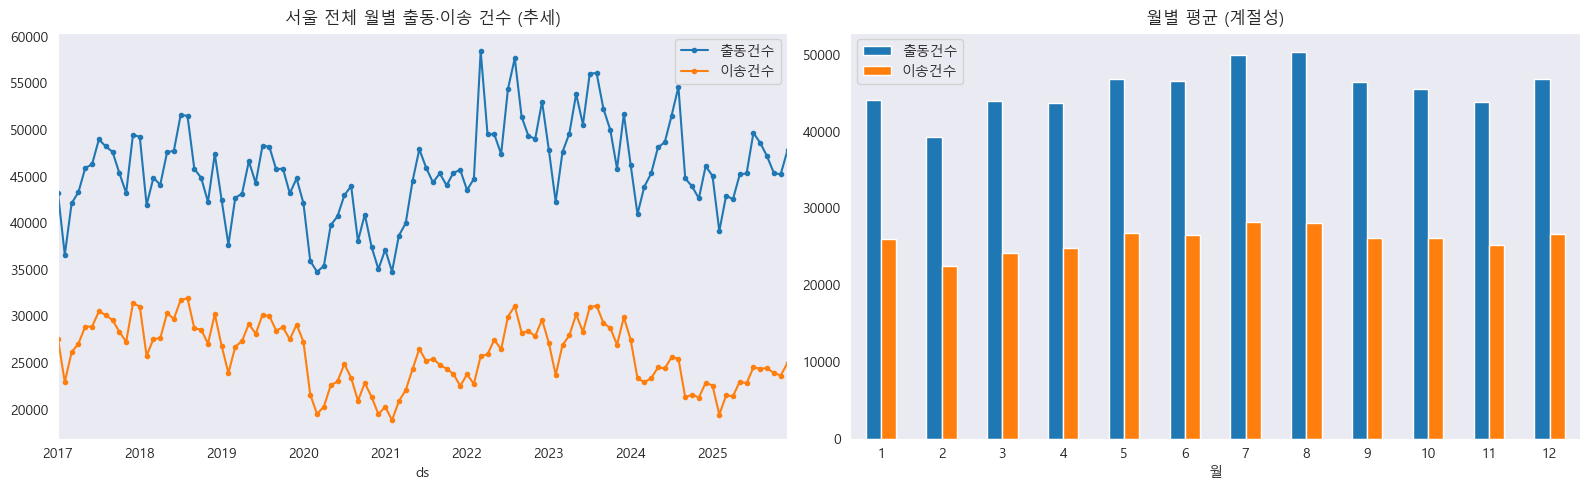

In [12]:
mdf = pd.read_csv(MODEL_PATH, parse_dates=["ds"])
seoul = mdf.groupby("ds")[["출동건수", "이송건수"]].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
seoul.plot(ax=axes[0], marker="o", markersize=3, title="서울 전체 월별 출동·이송 건수 (추세)")
seoul.groupby(seoul.index.month).mean().plot(kind="bar", ax=axes[1], rot=0, title="월별 평균 (계절성)")
axes[1].set_xlabel("월")
plt.tight_layout()
plt.show()

### 4-2. 마지막 월 자치구별 이송건수

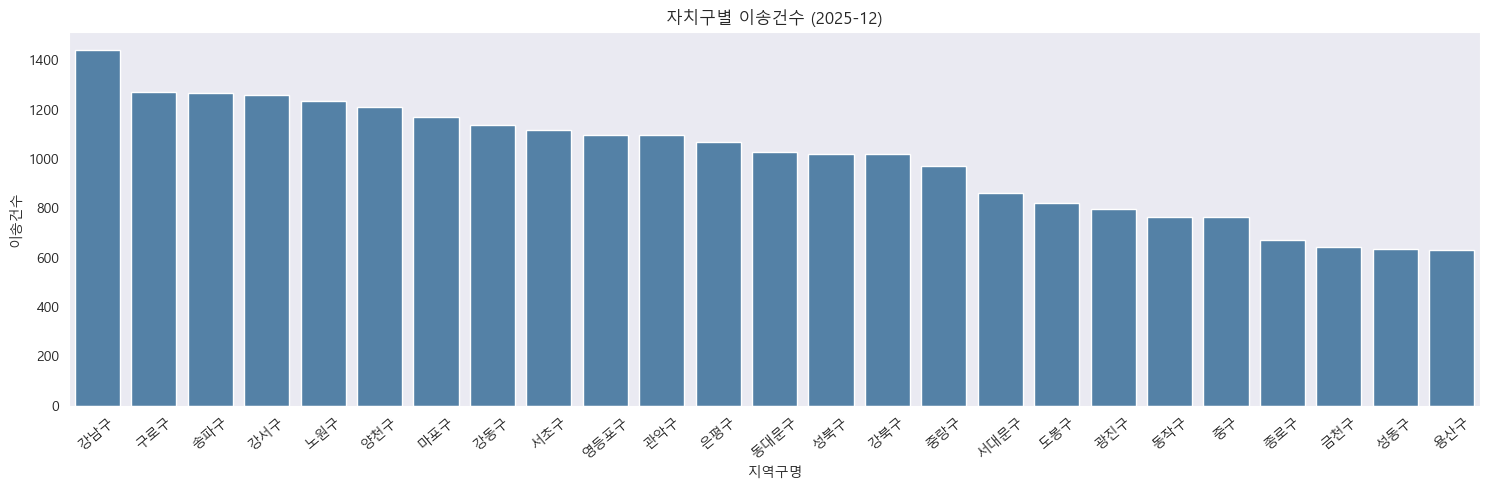

In [13]:
last = mdf[mdf["ds"] == mdf["ds"].max()].sort_values("이송건수", ascending=False)

plt.figure(figsize=(15, 5))
sns.barplot(data=last, x="지역구명", y="이송건수", color="steelblue")
plt.title(f"자치구별 이송건수 ({mdf['ds'].max():%Y-%m})")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

### 4-3. 자치구별 응급실 가용병상 (실시간)

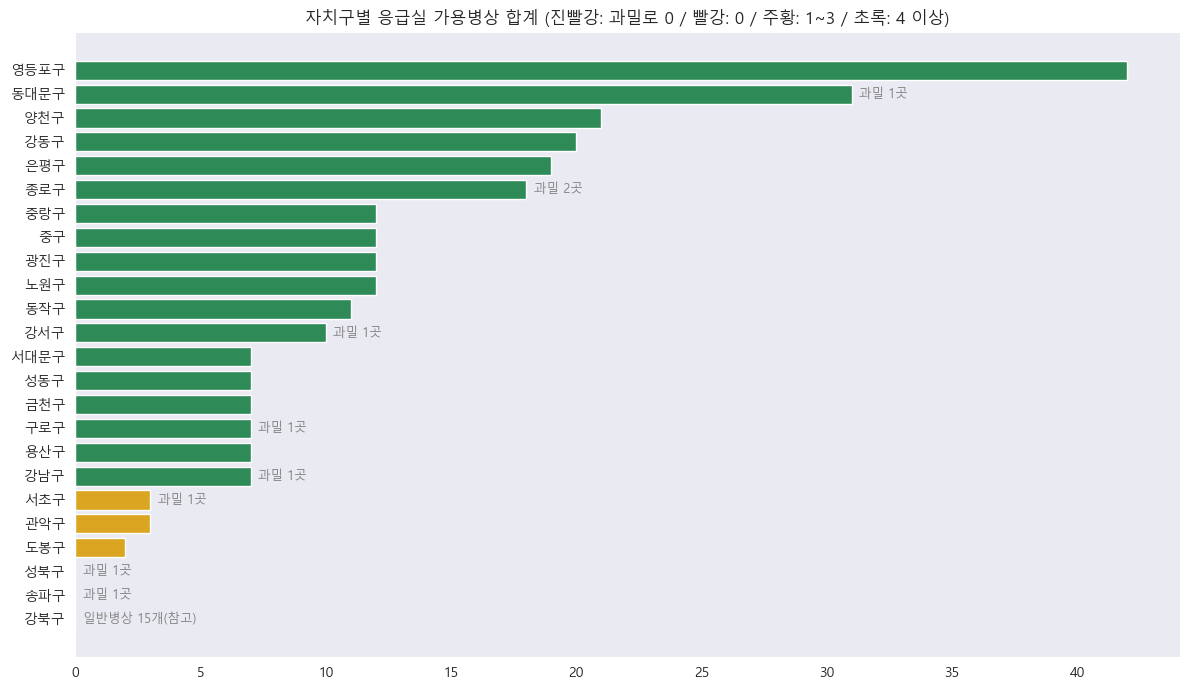

In [14]:
beds_df = add_bed_status(pd.read_csv(BEDS_PATH))   # 갱신 지연 여부를 현재 시각 기준으로 다시 계산
gu_beds = (beds_df.groupby("District", as_index=False)
                  .agg(beds=("Available_Beds", "sum"), over=("Is_Overcrowded", "sum"),
                       general=("General_Beds", "sum"))
                  .sort_values("beds"))
gu_beds["color"] = np.select([(gu_beds["beds"] == 0) & (gu_beds["over"] > 0), gu_beds["beds"] == 0, gu_beds["beds"] <= 3],
                             ["darkred", "crimson", "goldenrod"], "seagreen")

plt.figure(figsize=(12, 7))
plt.barh(gu_beds["District"], gu_beds["beds"], color=gu_beds["color"])
for i, (b, o, g) in enumerate(zip(gu_beds["beds"], gu_beds["over"], gu_beds["general"])):
    note = (f"과밀 {int(o)}곳 " if o else "") + (f"일반병상 {int(g)}개(참고)" if g else "")
    if note:
        plt.text(b + 0.3, i, note, va="center", fontsize=9, color="gray")
plt.title("자치구별 응급실 가용병상 합계 (진빨강: 과밀로 0 / 빨강: 0 / 주황: 1~3 / 초록: 4 이상)")
plt.tight_layout()
plt.show()

### 4-4. 병상 여유가 가장 적은 병원 TOP 10

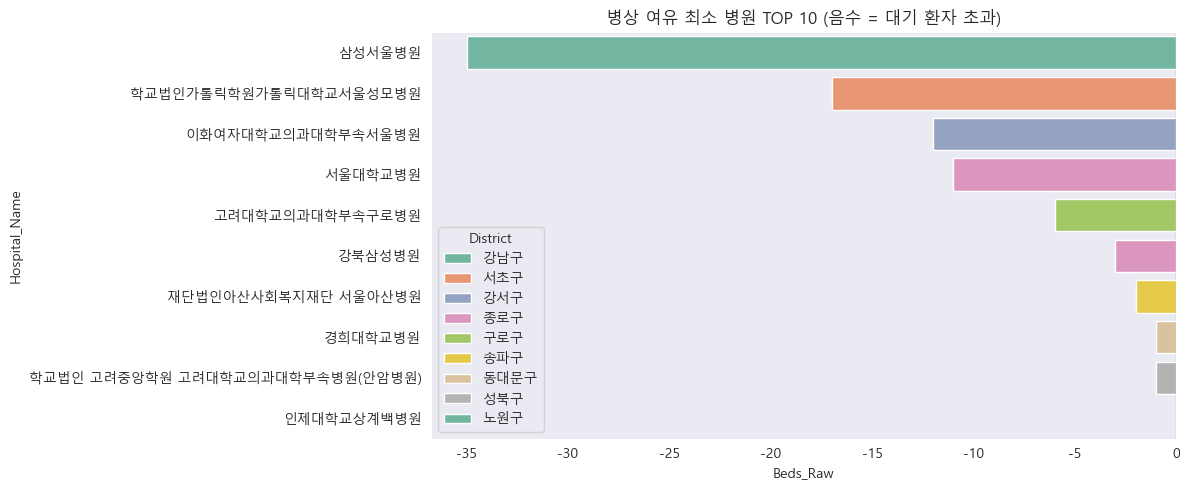

병상 정보를 알 수 없는 병원 없음 (강북구/마포구 제외)


In [15]:
top10 = beds_df[~beds_df["Beds_Unknown"]].nsmallest(10, "Beds_Raw")

plt.figure(figsize=(12, 5))
sns.barplot(data=top10, x="Beds_Raw", y="Hospital_Name", hue="District", dodge=False, palette="Set2")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("병상 여유 최소 병원 TOP 10 (음수 = 대기 환자 초과)")
plt.tight_layout()
plt.show()

unknown = beds_df["Beds_Unknown"] & beds_df["General_Beds"].isna()
if unknown.any():   # 일반병상 보완 병원은 제외
    display(beds_df[unknown][["District", "Hospital_Name", "Updated_At", "Is_Stale"]])
else:
    print("병상 정보를 알 수 없는 병원 없음 (강북구/마포구 제외)")